# 🍔 Food Calorie Detector — EfficientNetV2

This notebook trains an **EfficientNetV2-S** model to:
1. Classify food images into 63 categories
2. Map each predicted class to an estimated calorie range

**Pipeline overview:**
- Unzip & explore the dataset
- Build train / val / test splits
- Fine-tune EfficientNetV2-S (ImageNet pretrained)
- Evaluate & visualize results
- Run inference with calorie lookup on a new image

## 1 — Install & Import

In [7]:
# Install / upgrade key packages (run once)
!pip install -q torch torchvision timm matplotlib seaborn scikit-learn Pillow tqdm

In [8]:
import os, zipfile, random, json, math, copy
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


In [25]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("ROOT:", root)
    print("FILES:", files)

ROOT: /kaggle/input
FILES: []
ROOT: /kaggle/input/datasets
FILES: []
ROOT: /kaggle/input/datasets/nourannhassann
FILES: []
ROOT: /kaggle/input/datasets/nourannhassann/photos
FILES: []
ROOT: /kaggle/input/datasets/nourannhassann/photos/dataset
FILES: []
ROOT: /kaggle/input/datasets/nourannhassann/photos/dataset/chocolate
FILES: ['chocolate_61.jpg', 'chocolate_251.jpg', 'chocolate_110.jpg', 'chocolate_172.jpg', 'chocolate_123.jpg', 'chocolate_196.jpg', 'chocolate_12.jpg', 'chocolate_96.jpg', 'chocolate_115.jpg', 'chocolate_17.jpg', 'chocolate_136.jpg', 'chocolate_70.jpg', 'chocolate_211.jpg', 'chocolate_205.jpg', 'chocolate_241.jpg', 'chocolate_263.jpg', 'chocolate_222.jpg', 'chocolate_93.jpg', 'chocolate_139.jpg', 'chocolate_9.jpg', 'chocolate_104.jpg', 'chocolate_229.jpg', 'chocolate_23.jpg', 'chocolate_170.jpg', 'chocolate_158.jpg', 'chocolate_226.jpg', 'chocolate_204.jpg', 'chocolate_260.jpg', 'chocolate_255.jpg', 'chocolate_164.jpg', 'chocolate_192.jpg', 'chocolate_234.jpg', 'chocol

In [26]:
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(root, "→", f)

/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_61.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_251.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_110.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_172.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_123.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_196.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_12.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_96.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_115.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_17.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_136.jpg
/kaggle/input/datasets/nourannhassann/photos/dataset/chocolate → chocolate_70.jpg
/kaggle/i

In [27]:
import pandas as pd

file_path = "/kaggle/input/datasets/nourannhassann/efficent final_matched_dataset (1) - Copy.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/nourannhassann/efficent final_matched_dataset (1) - Copy.csv'

In [28]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/nourannhassann/efficent/dataset (6) (1)/dataset")

classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])

print(f"Found {len(classes)} classes:")
print(classes)

Found 64 classes:
['apple', 'bakery', 'banana', 'beef', 'bread', 'breakfast', 'broccoli', 'burger', 'burrito', 'butter', 'cake', 'carrot', 'cheese', 'chicken', 'chips', 'chocolate', 'coffee', 'cookies', 'corn', 'cream', 'cucumber', 'duck', 'falafel', 'fish', 'fried_chicken', 'garlic', 'grape', 'hummus', 'ice_cream', 'juice', 'kebab', 'lamb', 'lasagna', 'lettuce', 'mango', 'milk', 'noodles', 'oats', 'onion', 'orange', 'pasta', 'pineapple', 'pizza', 'popcorn', 'potato', 'quinoa', 'rice', 'salad', 'salmon', 'sandwich', 'shawarma', 'shrimp', 'smoothie', 'spinach', 'strawberry', 'sushi', 'sweet_potato', 'taco', 'tea', 'tomato', 'tuna', 'turkey', 'watermelon', 'yogurt']


## 3 — Dataset Exploration

Total images: 18120


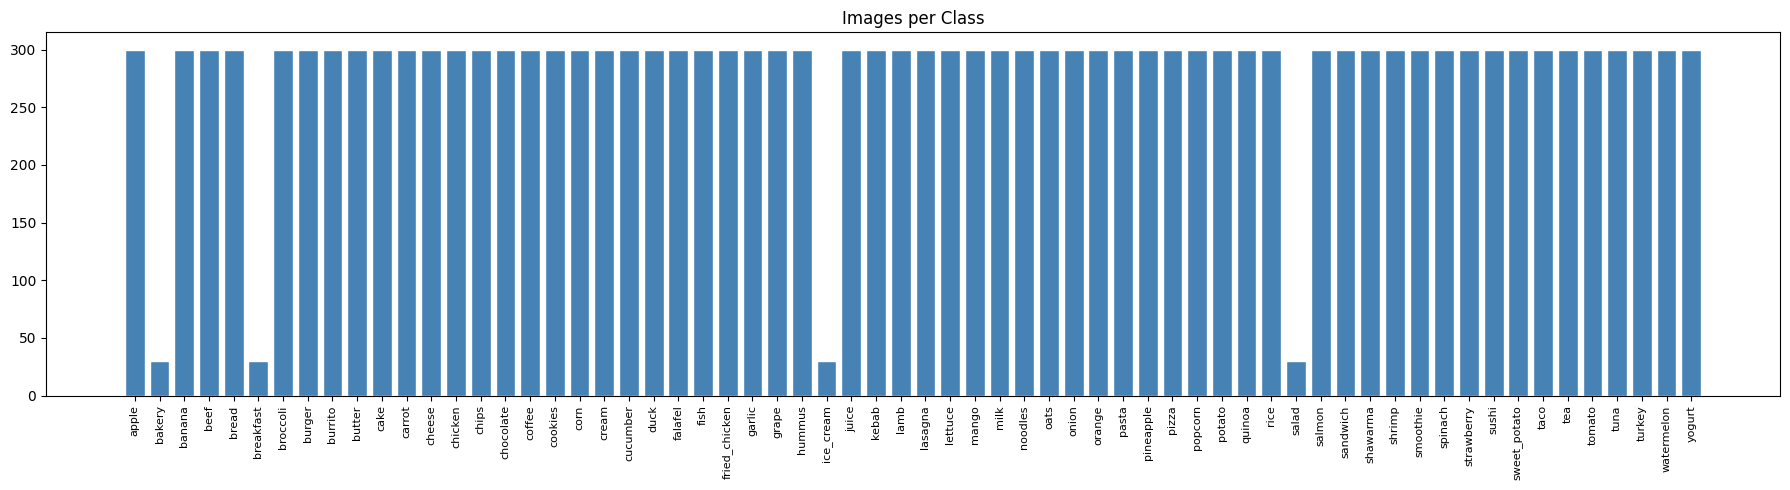

In [29]:
# Count images per class
counts = {cls: len(list((DATA_ROOT / cls).glob('*.*'))) for cls in classes}
total  = sum(counts.values())
print(f'Total images: {total}')

plt.figure(figsize=(18, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='white')
plt.xticks(rotation=90, fontsize=8)
plt.title('Images per Class')
plt.tight_layout()
plt.show()

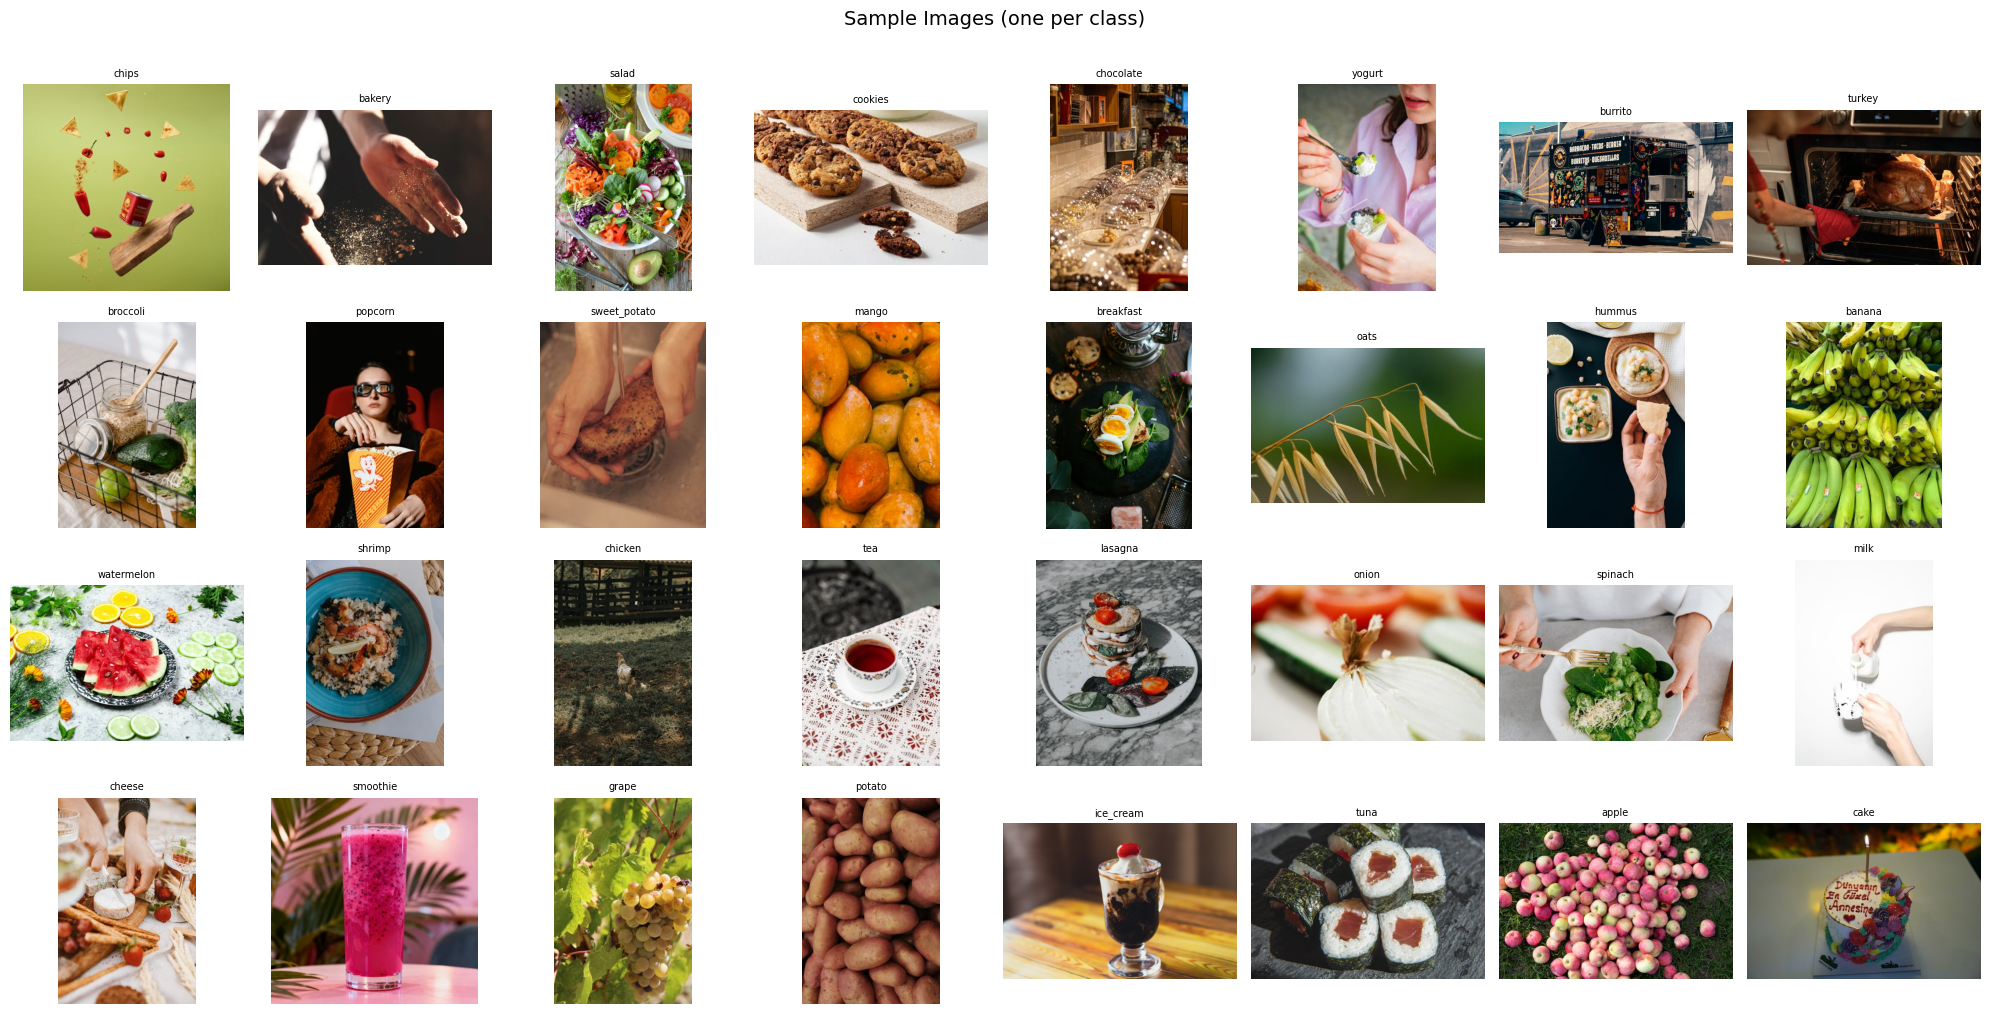

In [30]:
# Show a sample grid
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
sample_classes = random.sample(classes, min(32, len(classes)))
for ax, cls in zip(axes.flat, sample_classes):
    imgs = list((DATA_ROOT / cls).glob('*.*'))
    if imgs:
        img = Image.open(random.choice(imgs)).convert('RGB')
        ax.imshow(img)
    ax.set_title(cls, fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Images (one per class)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Calorie Lookup Table

Calories per **100 g** (approximate, based on standard nutritional references).  
The model predicts the class → we look up the calorie estimate.

In [42]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "csv" in f.lower():
            print(root + "/" + f)

/kaggle/input/datasets/nourannhassann/efficent/final_matched_dataset (1) - Copy.csv
/kaggle/input/datasets/nourannhassann/matched/final_matched_dataset (1) - Copy.csv


In [43]:
CSV_PATH = "/kaggle/input/matched/final_matched_dataset.csv"

CALORIE_TABLE = build_calorie_table(CSV_PATH, CLASS_TO_CSV)

(13829, 9)


,name,matched_name,ingredients,category,portion,calories,protein,fat,carb
0,chicken handi,chicken,"Chicken, Onion, Tomatoes, Garlic, Ginger paste...",meat,100 g,166.0,21.4,1.79,0.0
1,chicken mandi,chicken,"Chicken, Basmati Rice, Water, Onion, Garlic, G...",meat,100 g,166.0,21.4,1.79,0.0
2,sticky chicken,chicken,"Chicken drumsticks, Soy Sauce, Honey, Olive Oi...",meat,100 g,166.0,21.4,1.79,0.0
3,chicken congee,chicken,"Chicken, Salt, Pepper, Ginger Cordial, Ginger,...",meat,100 g,166.0,21.4,1.79,0.0
4,chicken karaage,chicken,"Chicken, Ginger, Garlic, Soy sauce, Sake, Gran...",meat,100 g,166.0,21.4,1.79,0.0


In [45]:
CSV_PATH = "/kaggle/input/datasets/nourannhassann/matched/final_matched_dataset (1) - Copy.csv"

CALORIE_TABLE = build_calorie_table(CSV_PATH, CLASS_TO_CSV)

In [47]:
import pandas as pd
from pathlib import Path

# ── Paths ─────────────────────────────────────────────
CSV_PATH = "/kaggle/input/datasets/nourannhassann/matched/final_matched_dataset (1) - Copy.csv"
DATA_ROOT = Path("/kaggle/input/datasets/nourannhassann/efficent/dataset (6) (1)/dataset")

# ── Extract classes from image folders ───────────────
classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])

# ── Class → CSV mapping ───────────────────────────────
CLASS_TO_CSV = {
    'apple':         'apple',
    'bakery':        'white bread',
    'banana':        'banana',
    'beef':          'beef',
    'bread':         'white bread',
    'breakfast':     'oats',
    'broccoli':      'broccoli',
    'burger':        'hamburger',
    'burrito':       'burrito',
    'butter':        'butter',
    'cake':          'yellow cake',
    'carrot':        'carrot',
    'cheese':        'cheddar cheese',
    'chicken':       'chicken',
    'chips':         'baked chips',
    'chocolate':     'chocolate bar',
    'coffee':        'coffee creamer',
    'cookies':       'cookies',
    'corn':          'corn',
    'cream':         'cream',
    'cucumber':      'cucumber',
    'duck':          'duck',
    'falafel':       'falafel',
    'fish':          'white fish',
    'fried_chicken': 'chicken breast fried',
    'garlic':        'garlic',
    'grape':         'grapes',
    'hummus':        'hummus',
    'ice_cream':     'vanilla ice cream',
    'juice':         'mango',
    'kebab':         'kebab',
    'lamb':          'lamb',
    'lasagna':       'lasagna',
    'lettuce':       'romaine lettuce',
    'mango':         'mango',
    'milk':          'oat milk',
    'noodles':       'egg noodles cooked',
    'oats':          'oats',
    'onion':         'onion',
    'orange':        'orange',
    'pasta':         'pasta',
    'pineapple':     'pineapple',
    'pizza':         'margherita pizza',
    'popcorn':       'popcorn air popped',
    'potato':        'white potato',
    'quinoa':        'quinoa',
    'rice':          'white rice cooked',
    'salad':         'mixed greens salad',
    'salmon':        'salmon',
    'sandwich':      'sandwich',
    'shawarma':      'kebab',
    'shrimp':        'shrimp',
    'smoothie':      'banana',
    'spinach':       'spinach',
    'strawberry':    'strawberries',
    'sushi':         'tuna sushi maki',
    'sweet_potato':  'sweet potato',
    'taco':          'taco',
    'tea':           'tea',
    'tomato':        'tomato',
    'tuna':          'tuna',
    'turkey':        'turkey',
    'watermelon':    'melon water melon',
    'yogurt':        'greek yogurt',
}

# ── Build calorie table ───────────────────────────────
def build_calorie_table(csv_path: str, class_to_csv: dict) -> dict:
    df = pd.read_csv(csv_path)
    
    table = {}
    for cls, csv_name in class_to_csv.items():
        rows = df[df['matched_name'] == csv_name]
        
        if rows.empty:
            print(f'⚠️ Missing in CSV: {csv_name} (class: {cls}) → set 0')
            table[cls] = 0
        else:
            table[cls] = round(rows['calories'].mean(), 1)
    
    return table


CALORIE_TABLE = build_calorie_table(CSV_PATH, CLASS_TO_CSV)

# ── Validation ────────────────────────────────────────
missing = [c for c in classes if c not in CALORIE_TABLE]

if missing:
    print(" Missing calorie entries:", missing)
else:
    print(" All classes have calorie entries!")

# ── Sample output ──────────────────────────────────────
print("\nSample values:")
for cls in list(CALORIE_TABLE)[:6]:
    print(f"{cls}: {CALORIE_TABLE[cls]} kcal / 100g")

✅ All classes have calorie entries!

Sample values:
apple: 64.0 kcal / 100g
bakery: 246.0 kcal / 100g
banana: 92.0 kcal / 100g
beef: 156.0 kcal / 100g
bread: 246.0 kcal / 100g
breakfast: 349.0 kcal / 100g


## 5 — Data Transforms & Splits

In [49]:
IMG_SIZE   = 224      # EfficientNetV2-S input size
BATCH_SIZE = 32
NUM_WORKERS = 2       # reduce to 0 if you hit Windows/Mac issues

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Load full dataset with train transforms first (we'll swap for val/test)
full_dataset = datasets.ImageFolder(str(DATA_ROOT), transform=train_tf)
NUM_CLASSES  = len(full_dataset.classes)
print(f'Classes ({NUM_CLASSES}): {full_dataset.classes}')

Classes (64): ['apple', 'bakery', 'banana', 'beef', 'bread', 'breakfast', 'broccoli', 'burger', 'burrito', 'butter', 'cake', 'carrot', 'cheese', 'chicken', 'chips', 'chocolate', 'coffee', 'cookies', 'corn', 'cream', 'cucumber', 'duck', 'falafel', 'fish', 'fried_chicken', 'garlic', 'grape', 'hummus', 'ice_cream', 'juice', 'kebab', 'lamb', 'lasagna', 'lettuce', 'mango', 'milk', 'noodles', 'oats', 'onion', 'orange', 'pasta', 'pineapple', 'pizza', 'popcorn', 'potato', 'quinoa', 'rice', 'salad', 'salmon', 'sandwich', 'shawarma', 'shrimp', 'smoothie', 'spinach', 'strawberry', 'sushi', 'sweet_potato', 'taco', 'tea', 'tomato', 'tuna', 'turkey', 'watermelon', 'yogurt']


In [50]:
# Stratified 70 / 15 / 15 split
from sklearn.model_selection import train_test_split

targets = np.array(full_dataset.targets)
indices = np.arange(len(targets))

train_idx, tmp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(
    tmp_idx, test_size=0.50,
    stratify=targets[tmp_idx], random_state=SEED)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

# Build subsets — val/test use val_tf
train_set = Subset(full_dataset, train_idx)

val_ds = datasets.ImageFolder(str(DATA_ROOT), transform=val_tf)
val_set  = Subset(val_ds, val_idx)
test_set = Subset(val_ds, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = full_dataset.classes

Train: 12684 | Val: 2718 | Test: 2718


## 6 — Build Model (EfficientNetV2-S)

In [51]:
def build_model(num_classes: int, freeze_backbone: bool = True):
    """
    EfficientNetV2-S pretrained on ImageNet-21k then fine-tuned on ImageNet-1k.
    We replace the classifier head for our food classes.
    """
    model = timm.create_model(
        'tf_efficientnetv2_s.in21k_ft_in1k',
        pretrained=True,
        num_classes=num_classes
    )

    if freeze_backbone:
        # Freeze everything except the classifier
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

    return model


model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total_p:,}')

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Trainable params: 81,984 / 20,259,472


## 7 — Training

In [54]:
# ─── Hyper-parameters ────────────────────────────────────────────────────────
EPOCHS_HEAD  = 5    # Phase 1: train head only
EPOCHS_FULL  = 15   # Phase 2: unfreeze & fine-tune entire network
LR_HEAD      = 1e-3
LR_FULL      = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_HEAD)

# ─── Training Loop ───────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None


def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += len(labels)
    return total_loss / n, correct / n


def train_phase(n_epochs, phase_name):
    global best_val_acc, best_weights
    print(f'\n{'='*55}')
    print(f'  Phase: {phase_name}  |  Epochs: {n_epochs}')
    print(f'{'='*55}')
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = run_epoch(train_loader, training=True)
        vl_loss, vl_acc = run_epoch(val_loader,   training=False)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        flag = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            flag = '  ← best'

        print(f'Epoch {epoch:02d}/{n_epochs} | '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc {tr_acc*100:.1f}%/{vl_acc*100:.1f}%{flag}')

In [55]:
# ── Phase 1: head only ────────────────────────────────────────────────────────
train_phase(EPOCHS_HEAD, 'Head only')

# ── Phase 2: unfreeze all layers and fine-tune ────────────────────────────────
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL)

train_phase(EPOCHS_FULL, 'Full fine-tune')

# Restore best checkpoint
model.load_state_dict(best_weights)
print(f'\n✅  Best val accuracy: {best_val_acc*100:.2f}%')


  Phase: Head only  |  Epochs: 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/397 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 05/5 | loss 1.9399/2.0734 | acc 64.8%/61.5%  ← best

  Phase: Full fine-tune  |  Epochs: 15


  0%|          | 0/397 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7824cef4b380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7824cef4b380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

KeyboardInterrupt: 

In [56]:
model.load_state_dict(best_weights)

torch.save(model.state_dict(), "efficientnet_best.pth")

print("Model saved successfully")

Model saved successfully


## 8 — Training Curves

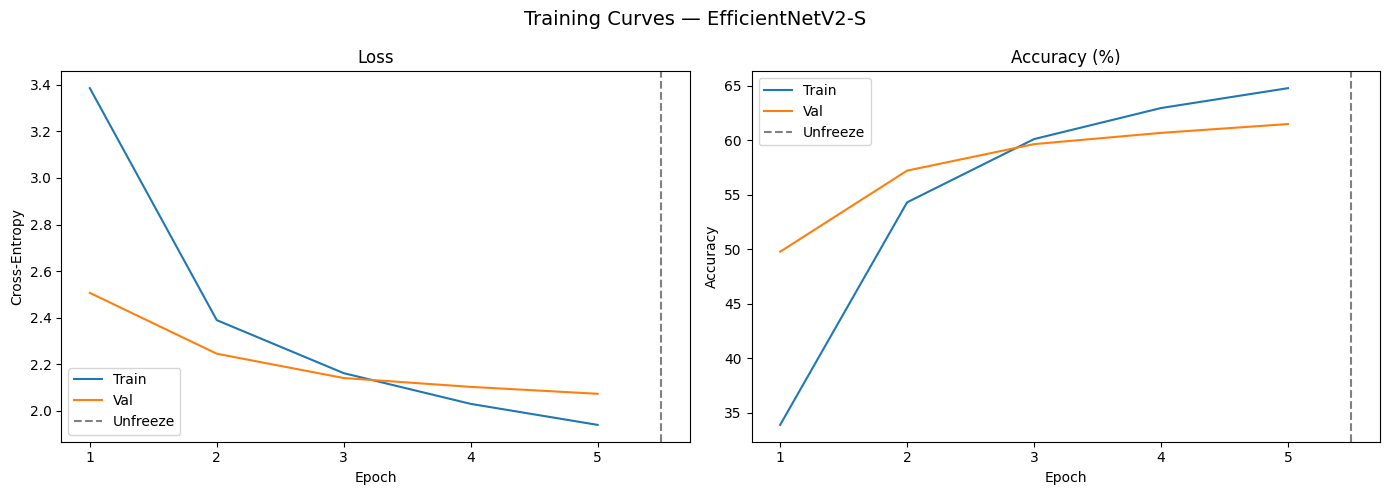

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history['train_loss']) + 1)
phase_split = EPOCHS_HEAD   # vertical line between phases

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.axvline(phase_split + 0.5, color='gray', linestyle='--', label='Unfreeze')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Cross-Entropy')
ax1.legend()

ax2.plot(epochs, [a*100 for a in history['train_acc']], label='Train')
ax2.plot(epochs, [a*100 for a in history['val_acc']],   label='Val')
ax2.axvline(phase_split + 0.5, color='gray', linestyle='--', label='Unfreeze')
ax2.set(title='Accuracy (%)', xlabel='Epoch', ylabel='Accuracy')
ax2.legend()

plt.suptitle('Training Curves — EfficientNetV2-S', fontsize=14)
plt.tight_layout()
plt.show()

## 9 — Test-Set Evaluation

In [59]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Test'):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc*100:.2f}%\n')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))

Test:   0%|          | 0/85 [00:00<?, ?it/s]

Test Accuracy: 62.51%

               precision    recall  f1-score   support

        apple      0.889     0.889     0.889        45
       bakery      0.000     0.000     0.000         5
       banana      0.935     0.956     0.945        45
         beef      0.415     0.489     0.449        45
        bread      0.554     0.800     0.655        45
    breakfast      0.000     0.000     0.000         4
     broccoli      0.621     0.800     0.699        45
       burger      0.795     0.778     0.787        45
      burrito      0.345     0.444     0.388        45
       butter      0.583     0.311     0.406        45
         cake      0.688     0.733     0.710        45
       carrot      0.643     0.600     0.621        45
       cheese      0.606     0.444     0.513        45
      chicken      0.955     0.933     0.944        45
        chips      0.453     0.533     0.490        45
    chocolate      0.720     0.800     0.758        45
       coffee      0.681     0.711     0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


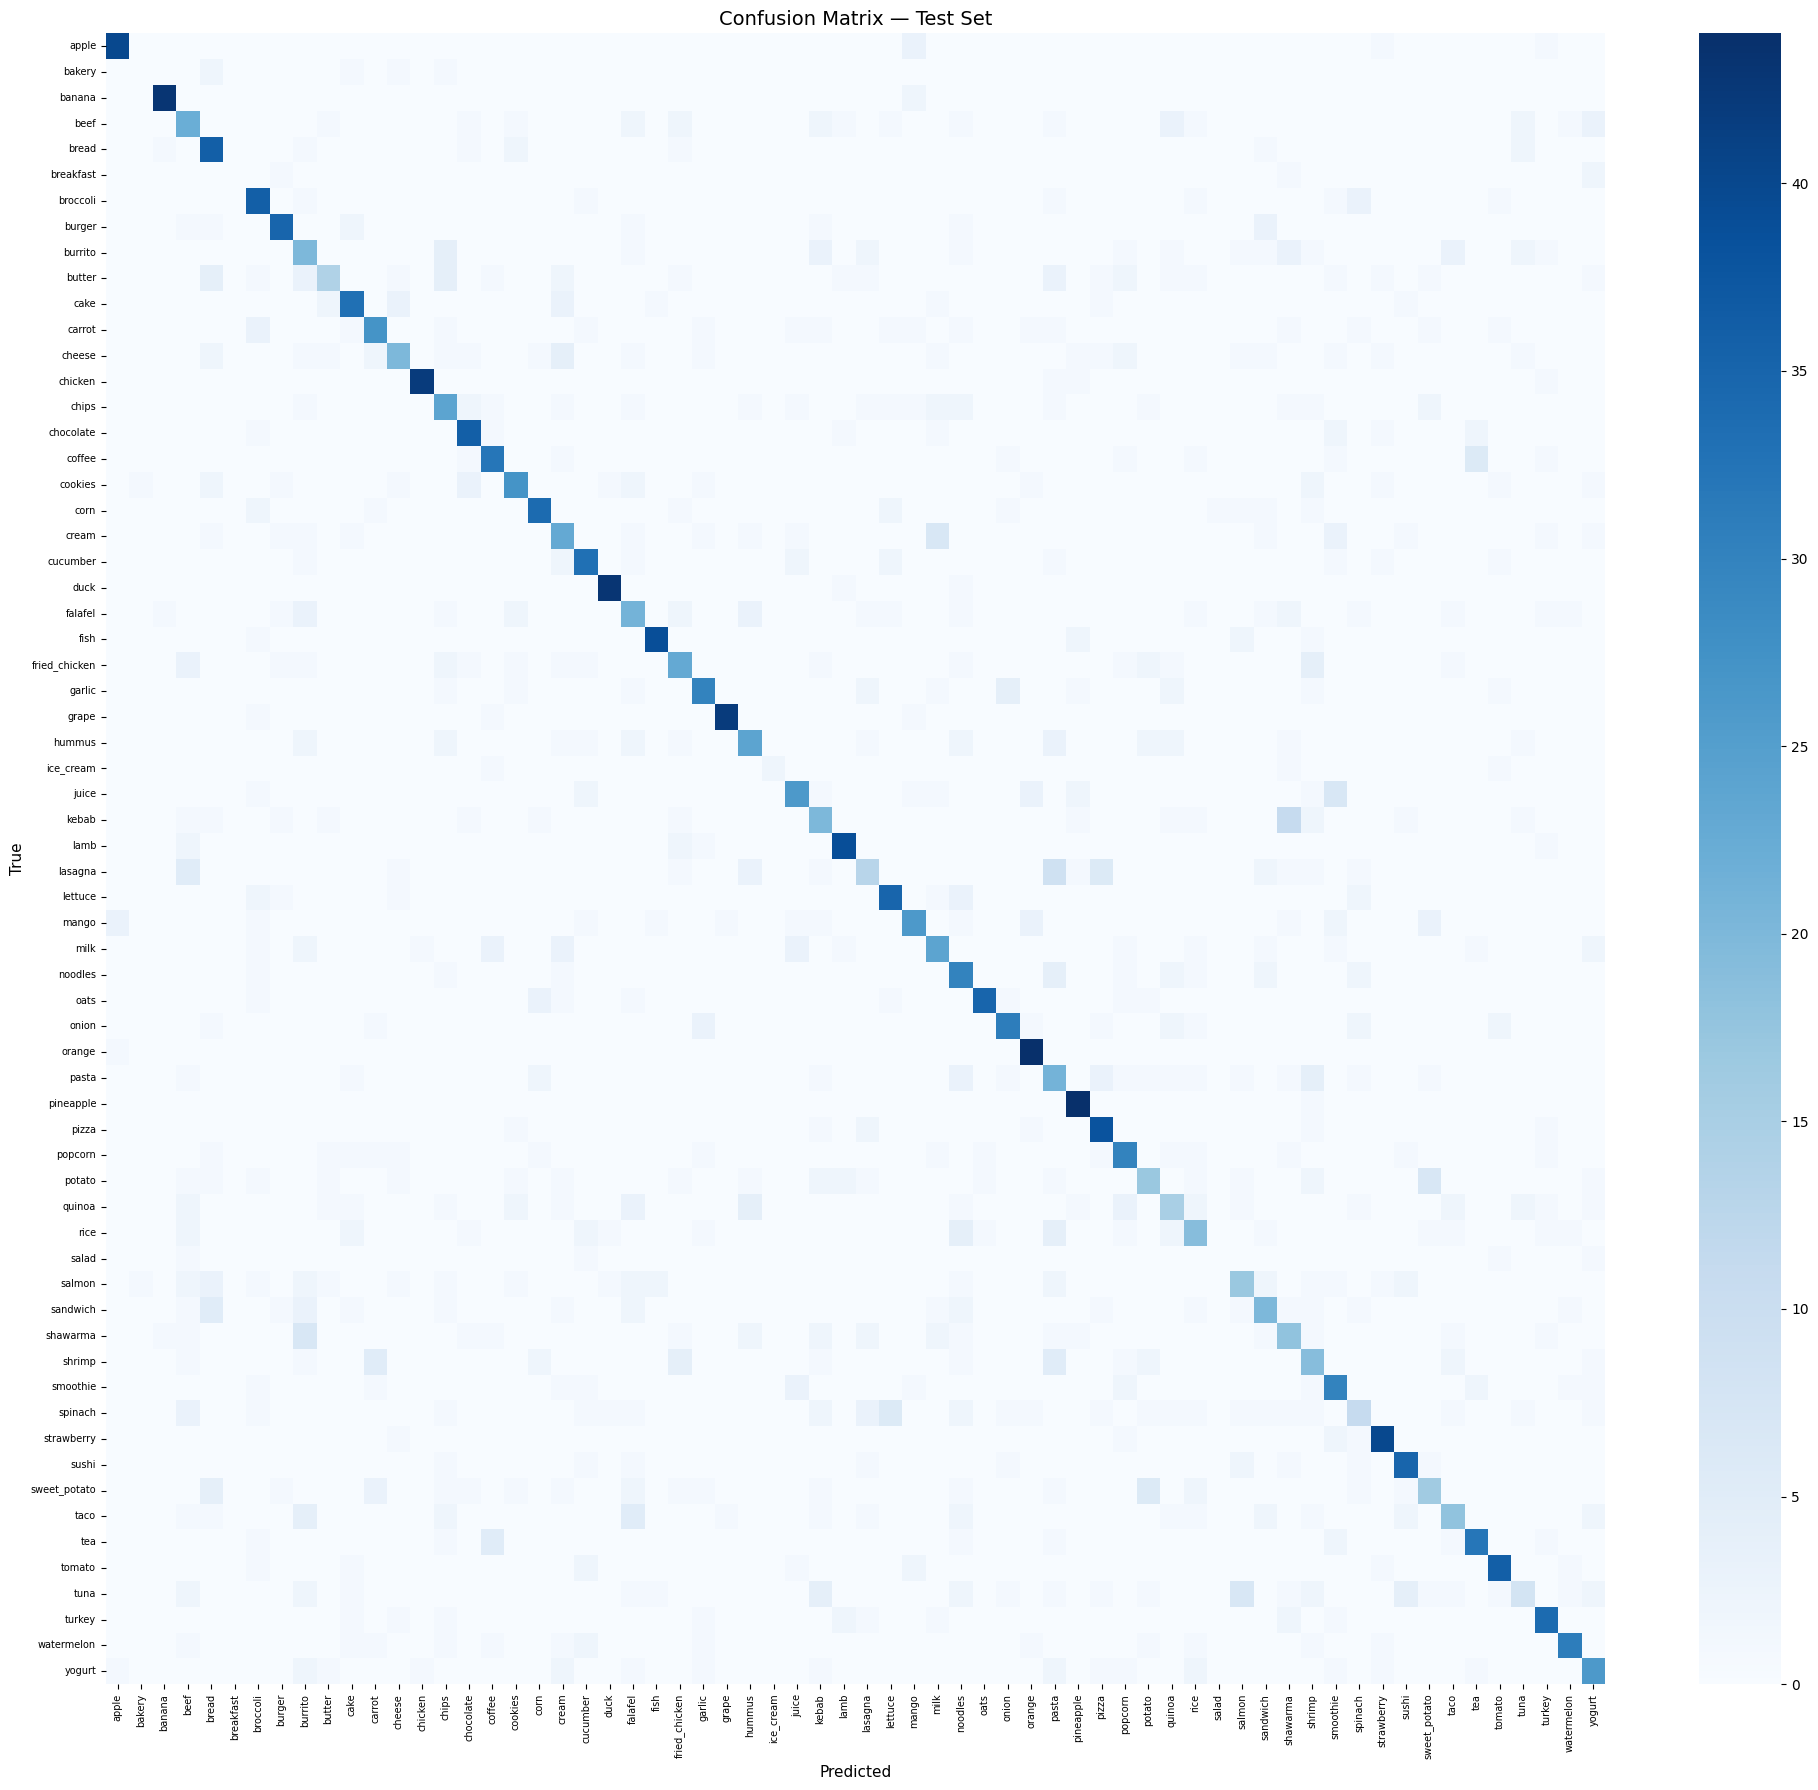

In [60]:
# Confusion matrix (top-N classes by count for readability)
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

## 10 — Inference with Calorie Estimation

In [61]:
def predict_calories(image_path: str, top_k: int = 5, serving_g: int = 150):
    """
    Parameters
    ----------
    image_path : path to any food image
    top_k      : show top-k predicted classes with probabilities
    serving_g  : assumed serving size in grams for calorie calculation

    Calorie values are looked up from CALORIE_TABLE, which is built
    dynamically from the matched dataset CSV (kcal per 100 g).

    Returns
    -------
    dict with predicted class, confidence, and estimated calories
    """
    img = Image.open(image_path).convert('RGB')
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    top_probs, top_idxs = probs.topk(top_k)
    top_probs = top_probs.cpu().numpy()
    top_idxs  = top_idxs.cpu().numpy()

    # ── Visualize ────────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))

    ax_img.imshow(img)
    ax_img.axis('off')
    ax_img.set_title(image_path, fontsize=9)

    labels = [CLASS_NAMES[i] for i in top_idxs]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(top_k)]
    bars   = ax_bar.barh(labels[::-1], top_probs[::-1] * 100,
                          color=colors[::-1], edgecolor='white')
    ax_bar.set_xlabel('Confidence (%)')
    ax_bar.set_title(f'Top-{top_k} Predictions')
    ax_bar.set_xlim(0, 100)

    for bar, prob in zip(bars[::-1], top_probs):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{prob*100:.1f}%', va='center', fontsize=9)

    # ── CSV-based calorie lookup ──────────────────────────────────────────────
    best_class   = CLASS_NAMES[top_idxs[0]]
    confidence   = top_probs[0]
    csv_name     = CLASS_TO_CSV.get(best_class, best_class)   # mapped CSV entry
    cal_per_100g = CALORIE_TABLE.get(best_class, 0)
    cal_serving  = cal_per_100g * serving_g / 100

    info = (f'Predicted: {best_class.upper()}  ({confidence*100:.1f}%)\n'
            f'CSV entry: "{csv_name}" → {cal_per_100g} kcal / 100 g'
            f'  ≈  {cal_serving:.0f} kcal / {serving_g} g serving')
    ax_bar.set_xlabel(info, fontsize=10)

    plt.tight_layout()
    plt.show()

    return {
        'predicted_class':         best_class,
        'csv_matched_name':        csv_name,
        'confidence':              round(float(confidence), 4),
        'cal_per_100g':            cal_per_100g,
        f'cal_per_{serving_g}g':   round(cal_serving, 1),
        'top_k': [(CLASS_NAMES[i], round(float(p), 4))
                  for i, p in zip(top_idxs, top_probs)],
    }


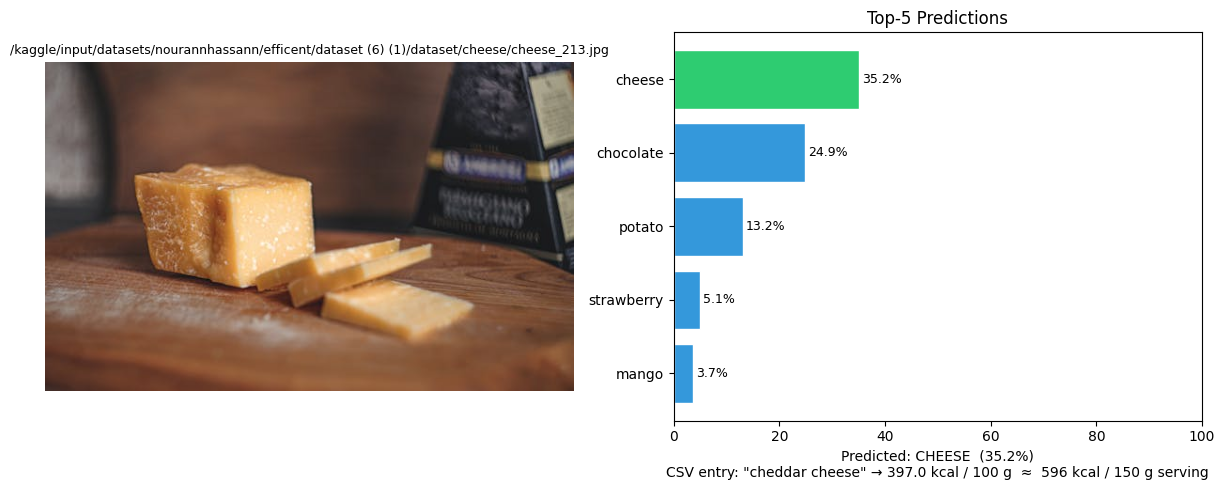

{
  "predicted_class": "cheese",
  "csv_matched_name": "cheddar cheese",
  "confidence": 0.3516,
  "cal_per_100g": 397.0,
  "cal_per_150g": 595.5,
  "top_k": [
    [
      "cheese",
      0.3516
    ],
    [
      "chocolate",
      0.249
    ],
    [
      "potato",
      0.1316
    ],
    [
      "strawberry",
      0.0505
    ],
    [
      "mango",
      0.0366
    ]
  ]
}



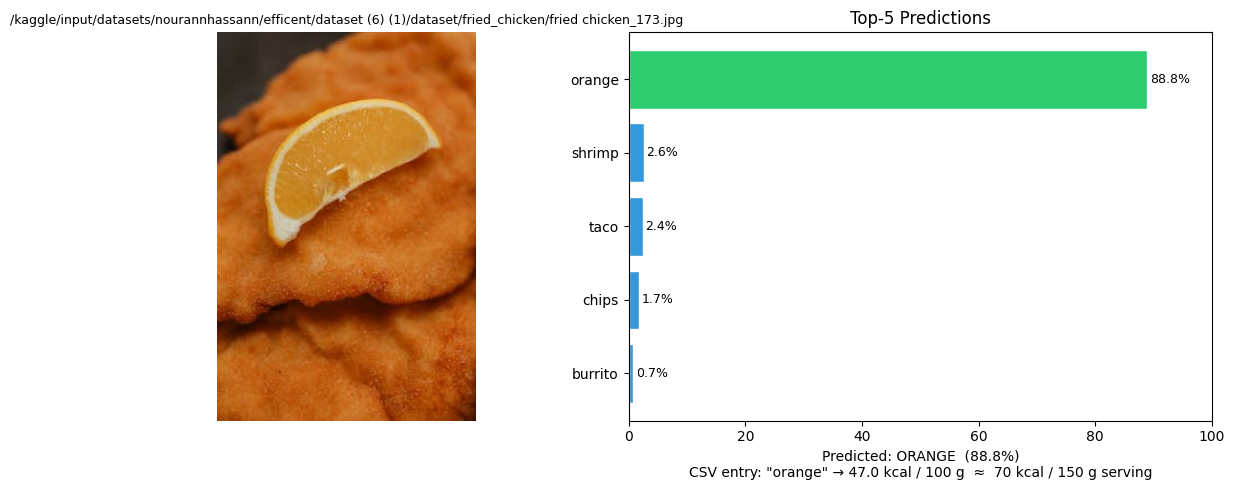

{
  "predicted_class": "orange",
  "csv_matched_name": "orange",
  "confidence": 0.8884,
  "cal_per_100g": 47.0,
  "cal_per_150g": 70.5,
  "top_k": [
    [
      "orange",
      0.8884
    ],
    [
      "shrimp",
      0.0256
    ],
    [
      "taco",
      0.024
    ],
    [
      "chips",
      0.0171
    ],
    [
      "burrito",
      0.0073
    ]
  ]
}



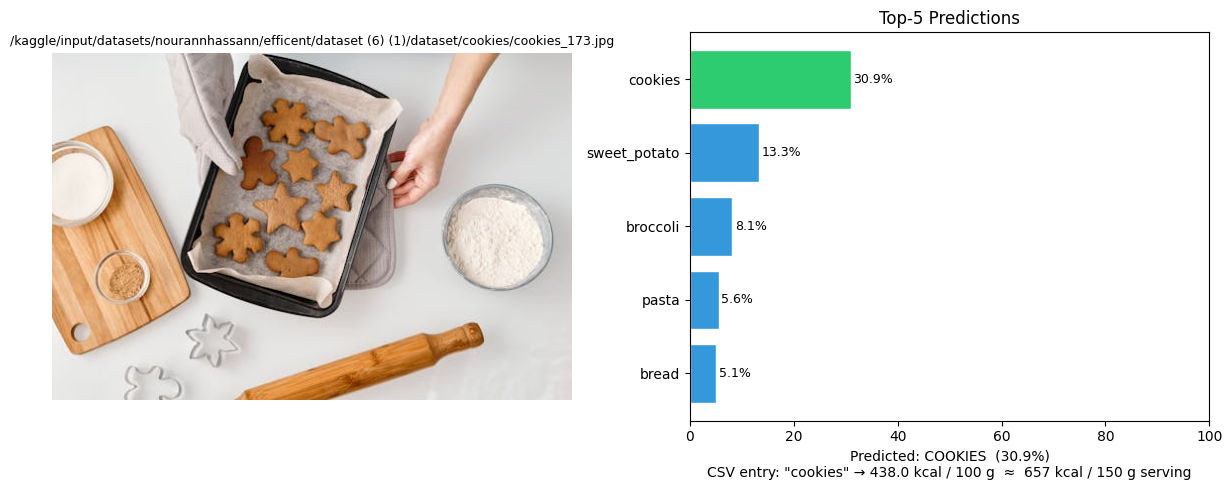

{
  "predicted_class": "cookies",
  "csv_matched_name": "cookies",
  "confidence": 0.3093,
  "cal_per_100g": 438.0,
  "cal_per_150g": 657.0,
  "top_k": [
    [
      "cookies",
      0.3093
    ],
    [
      "sweet_potato",
      0.1329
    ],
    [
      "broccoli",
      0.0811
    ],
    [
      "pasta",
      0.0556
    ],
    [
      "bread",
      0.0505
    ]
  ]
}



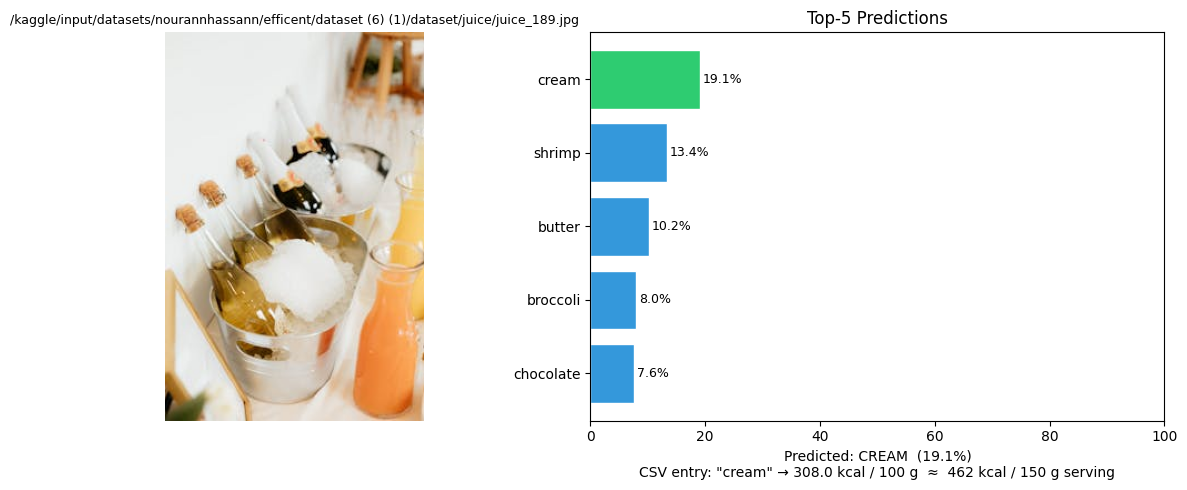

{
  "predicted_class": "cream",
  "csv_matched_name": "cream",
  "confidence": 0.191,
  "cal_per_100g": 308.0,
  "cal_per_150g": 462.0,
  "top_k": [
    [
      "cream",
      0.191
    ],
    [
      "shrimp",
      0.1338
    ],
    [
      "butter",
      0.1024
    ],
    [
      "broccoli",
      0.0798
    ],
    [
      "chocolate",
      0.0761
    ]
  ]
}



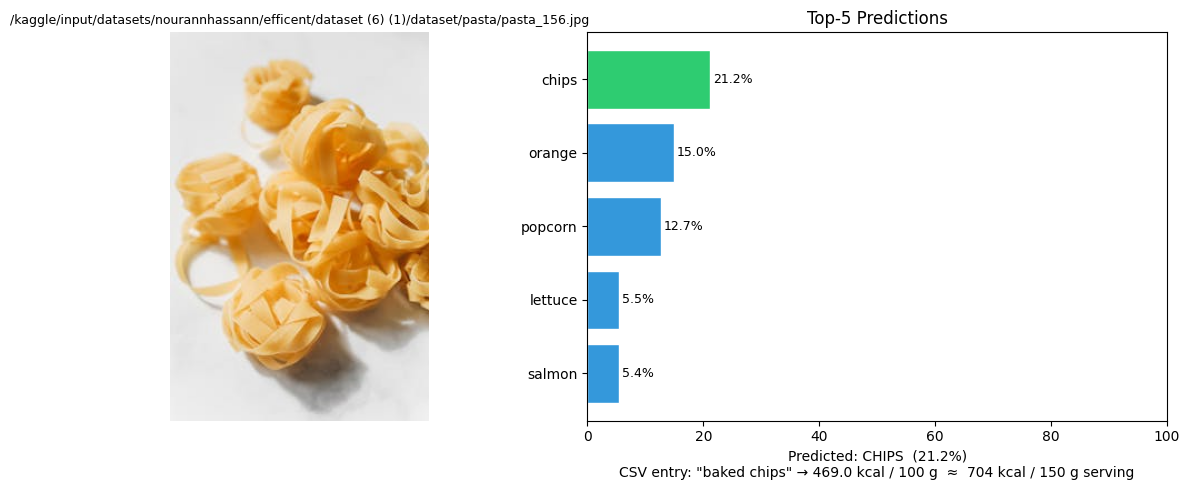

{
  "predicted_class": "chips",
  "csv_matched_name": "baked chips",
  "confidence": 0.2122,
  "cal_per_100g": 469.0,
  "cal_per_150g": 703.5,
  "top_k": [
    [
      "chips",
      0.2122
    ],
    [
      "orange",
      0.1498
    ],
    [
      "popcorn",
      0.1266
    ],
    [
      "lettuce",
      0.0547
    ],
    [
      "salmon",
      0.0541
    ]
  ]
}



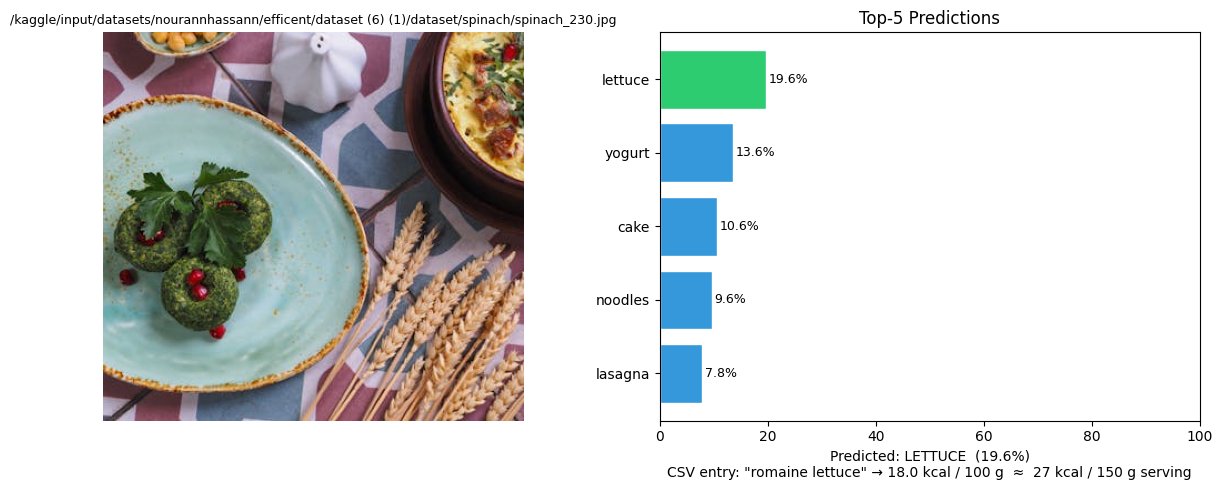

{
  "predicted_class": "lettuce",
  "csv_matched_name": "romaine lettuce",
  "confidence": 0.1965,
  "cal_per_100g": 18.0,
  "cal_per_150g": 27.0,
  "top_k": [
    [
      "lettuce",
      0.1965
    ],
    [
      "yogurt",
      0.1363
    ],
    [
      "cake",
      0.1057
    ],
    [
      "noodles",
      0.0964
    ],
    [
      "lasagna",
      0.0785
    ]
  ]
}



In [62]:
# ── Quick demo on random test images ─────────────────────────────────────────
sample_paths = []
for cls in random.sample(classes, 6):
    imgs = list((DATA_ROOT / cls).glob('*.*'))
    if imgs:
        sample_paths.append(str(random.choice(imgs)))

for path in sample_paths:
    result = predict_calories(path, top_k=5, serving_g=150)
    print(json.dumps(result, indent=2))
    print()

## 11 — Save / Load the Model

In [63]:
# ── Save ─────────────────────────────────────────────────────────────────────
SAVE_PATH = 'food_calorie_efficientnetv2s.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'calorie_table':    CALORIE_TABLE,
    'num_classes':      NUM_CLASSES,
    'best_val_acc':     best_val_acc,
}, SAVE_PATH)
print(f'Model saved → {SAVE_PATH}')


# ── Load (example) ───────────────────────────────────────────────────────────
def load_model(checkpoint_path: str):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    m = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k',
                          pretrained=False,
                          num_classes=ckpt['num_classes'])
    m.load_state_dict(ckpt['model_state_dict'])
    m.to(DEVICE).eval()
    return m, ckpt['class_names'], ckpt['calorie_table']

# model, CLASS_NAMES, CALORIE_TABLE = load_model(SAVE_PATH)

Model saved → food_calorie_efficientnetv2s.pth


## 12 — Predict on Your Own Image

In [69]:
#  Change this to any food photo on your machine
MY_IMAGE = 'path/to/your/food_image.jpg'

if os.path.exists(MY_IMAGE):
    result = predict_calories(MY_IMAGE, top_k=5, serving_g=200)
    print(json.dumps(result, indent=2))
else:
    print('  File not found — update MY_IMAGE path above.')

FileUpload(value=(), accept='image/*', description='Upload')

---
## Summary

| Component | Choice | Why |
|---|---|---|
| Backbone | EfficientNetV2-S | Best accuracy/speed tradeoff; pre-trained on ImageNet-21k |
| Head | Single Linear layer | Simple, avoids overfitting on small datasets |
| Training | 2-phase (head → full) | Prevents early feature destruction |
| Loss | CrossEntropy + label smoothing | Reduces overconfidence |
| Augmentation | Crop, flip, color jitter, rotate | Improves generalization |
| Calorie output | Lookup table (kcal/100 g) | Precise enough for a prototype; extendable with a regressor |